In [1]:
from jax_signatures.signature import * 
from jax_signatures.exact_representations import * 
from schemes import * 
from trajectories import *
from utils import *

from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
import time 
import yfinance as yf

## I. Forecasting VIX index 

In [2]:
load_from = pd.to_datetime('1990-01-01')
train_start_date = pd.to_datetime('2000-01-01')
test_start_date = pd.to_datetime('2019-01-01') 
test_end_date = pd.to_datetime('2026-03-15')

In [3]:
SPX_data = yf.Ticker("^GSPC").history(start=load_from, end=test_end_date)
VIX_data = yf.Ticker("^VIX").history(start=load_from, end=test_end_date)
SPX_data.index = pd.to_datetime(SPX_data.index.date)
VIX_data.index = pd.to_datetime(VIX_data.index.date)
index = SPX_data.index
SPX = SPX_data['Close']
VIX = VIX_data['Close'] / 100

idx_train = np.where(index >= train_start_date)[0][0]
idx_test = np.where(index >= test_start_date)[0][0]

t_grid = np.array((index - index[0]).days / 365)
dates_grid = pd.to_datetime(pd.Series(index))

### I.1. Regression for fixed $M$ and varying $\boldsymbol{\lambda} = (\lambda^1, \lambda^2, \lambda^3)$ where $\lambda^1 = \lambda^2=\lambda^3$

In [308]:
t_grid_ = t_grid - t_grid[idx_train-1]
path = np.vstack([t_grid_, np.log(SPX) / 10,
    np.concatenate([[0], np.cumsum(np.diff(np.log(SPX))**2)]) * 2,
]).T
lambda_values = np.linspace(1, 21) 
M = 2
Y = np.array(VIX[idx_train-1:])

Y_EFM_values, RMSE_values, l_values = [], [], []

for lambd in tqdm(lambda_values) : 
    sig_EFM = compute_EFM_signature_one_path(path, M, t_grid_, lambd)
    model_EFM_Ridge, Y_EFM_Ridge, rmse_EFM_Ridge, _ = regression_Ridge(Y, sig_EFM, M, idx_train-1, idx_train-1, verbose=False)  
    coef_Ridge = get_full_coef(model_EFM_Ridge)
    l_Ridge = Tensor(array=jnp.asarray(coef_Ridge), M=M, d=3)
    Y_EFM_values.append(Y_EFM_Ridge)
    l_values.append(l_Ridge)
    RMSE_values.append(rmse_EFM_Ridge)

100%|███████████████████████████████████████████| 50/50 [00:09<00:00,  5.47it/s]


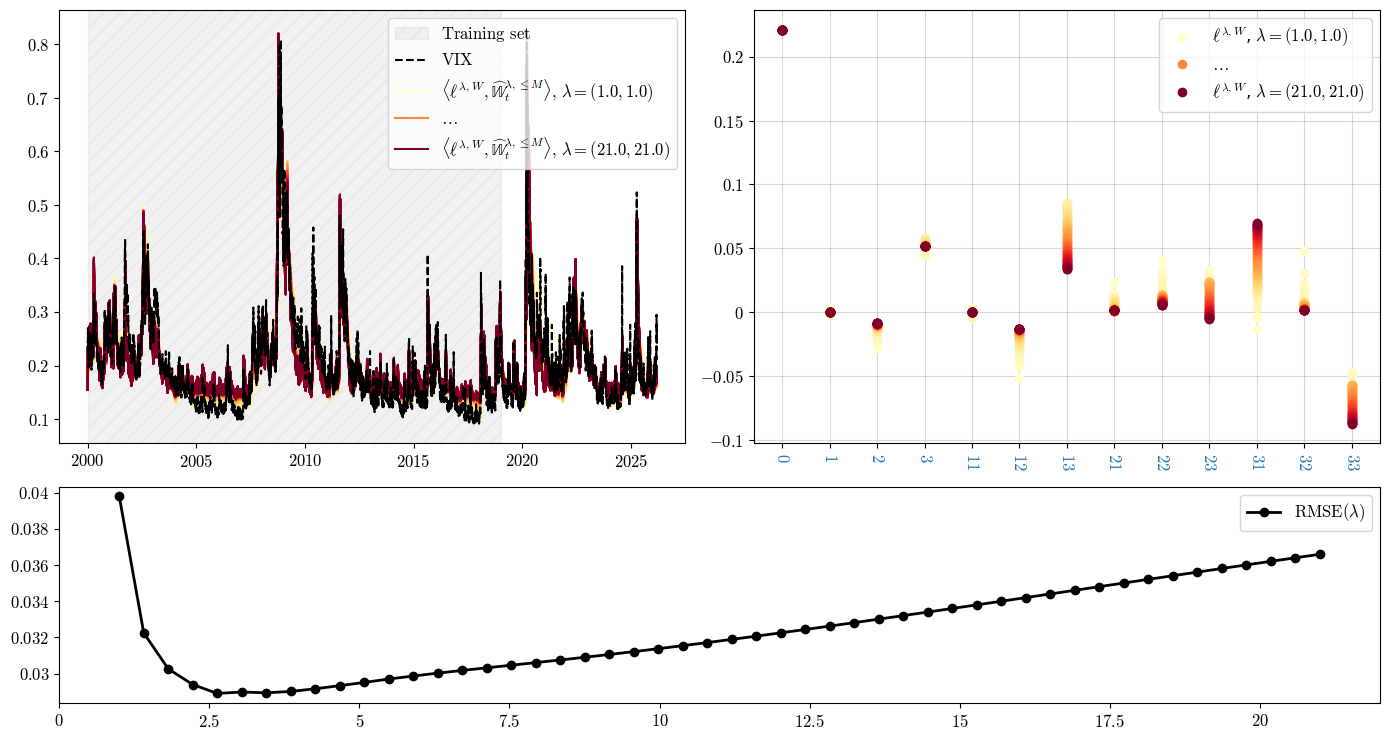

In [310]:
cmap = plt.get_cmap("YlOrRd", len(lambda_values))
norm = mcolors.Normalize(vmin=lambda_values.min(), vmax=lambda_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig = plt.figure(figsize=(14, 7.5))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

ax = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, :]),
]
ax[0].axvspan(xmin=dates_grid[idx_train-1], xmax=dates_grid[idx_test], color="lightgray", hatch="//", alpha=0.30, label=r"$\text{Training set}$", zorder=0)
ax[0].plot(dates_grid[idx_train-1:], Y, color="black", label=r"$\text{VIX}$", zorder=1, linestyle="--")
for i, lambd in enumerate(lambda_values) : 
    color = cmap(norm(lambd))
    if i == 0 or i == len(lambda_values)-1 : 
        ax[0].plot(dates_grid[idx_train-1:], Y_EFM_values[i], color=color, zorder=0, label=r"$\left\langle \ell^{\lambda, W}, \widehat{\mathbb{W}}_t^{\lambda, \leq M}\right\rangle,\,$" + fr"$\lambda={(float(np.round(lambd, 2)), float(np.round(lambd, 2)))}$")  
        l_values[i].plot(ax=ax[1], color=color, label=r"$\ell^{\lambda, W}$, "+fr"$\lambda={(float(np.round(lambd, 2)), float(np.round(lambd, 2)))}$")  
    elif i == len(lambda_values)//2 :
        ax[0].plot(dates_grid[idx_train-1:], Y_EFM_values[i], color=color, zorder=0, label=r"$\ldots$")
        l_values[i].plot(ax=ax[1], color=color, label=r"$\ldots$")
    else : 
        ax[0].plot(dates_grid[idx_train-1:], Y_EFM_values[i], color=color, zorder=0)
        l_values[i].plot(ax=ax[1], color=color)
ax[2].plot(lambda_values, RMSE_values, "o-", lw=2, color="black", label=r"$\text{RMSE}(\lambda)$")

for i in [0,2] : 
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(labelsize=12, axis="both")
    ax[i].legend(fontsize=12)

ax[0].xaxis.set_major_locator(mdates.YearLocator(5))        
ax[0].xaxis.set_major_formatter(mdates.DateFormatter(r"$%Y$"))
ax[2].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
plt.tight_layout()
plt.show()

### I.2. Regression for fixed $\boldsymbol{\lambda}$ with varying $M$ 

In [274]:
t_grid_ = t_grid - t_grid[idx_train-1]
path = np.vstack([t_grid_, np.log(SPX) / 10,
    np.concatenate([[0], np.cumsum(np.diff(np.log(SPX))**2)]) * 2,
]).T
M_values = np.arange(1, 6) 
Y = np.array(VIX[idx_train-1:])

Y_EFM_values, RMSE_values, l_values = [], [], []

lambd = 5.

for M in tqdm(M_values) : 
    sig_EFM = compute_EFM_signature_one_path(path, M, t_grid_, lambd)
    model_EFM_Ridge, Y_EFM_Ridge, rmse_EFM_Ridge, _ = regression_Ridge(Y, sig_EFM, M, idx_train-1, idx_train-1, verbose=False)  
    coef_Ridge = get_full_coef(model_EFM_Ridge)
    l_Ridge = Tensor(array=jnp.asarray(coef_Ridge), M=M, d=3)
    Y_EFM_values.append(Y_EFM_Ridge)
    l_values.append(l_Ridge)
    RMSE_values.append(rmse_EFM_Ridge)

100%|█████████████████████████████████████████████| 5/5 [00:11<00:00,  2.24s/it]


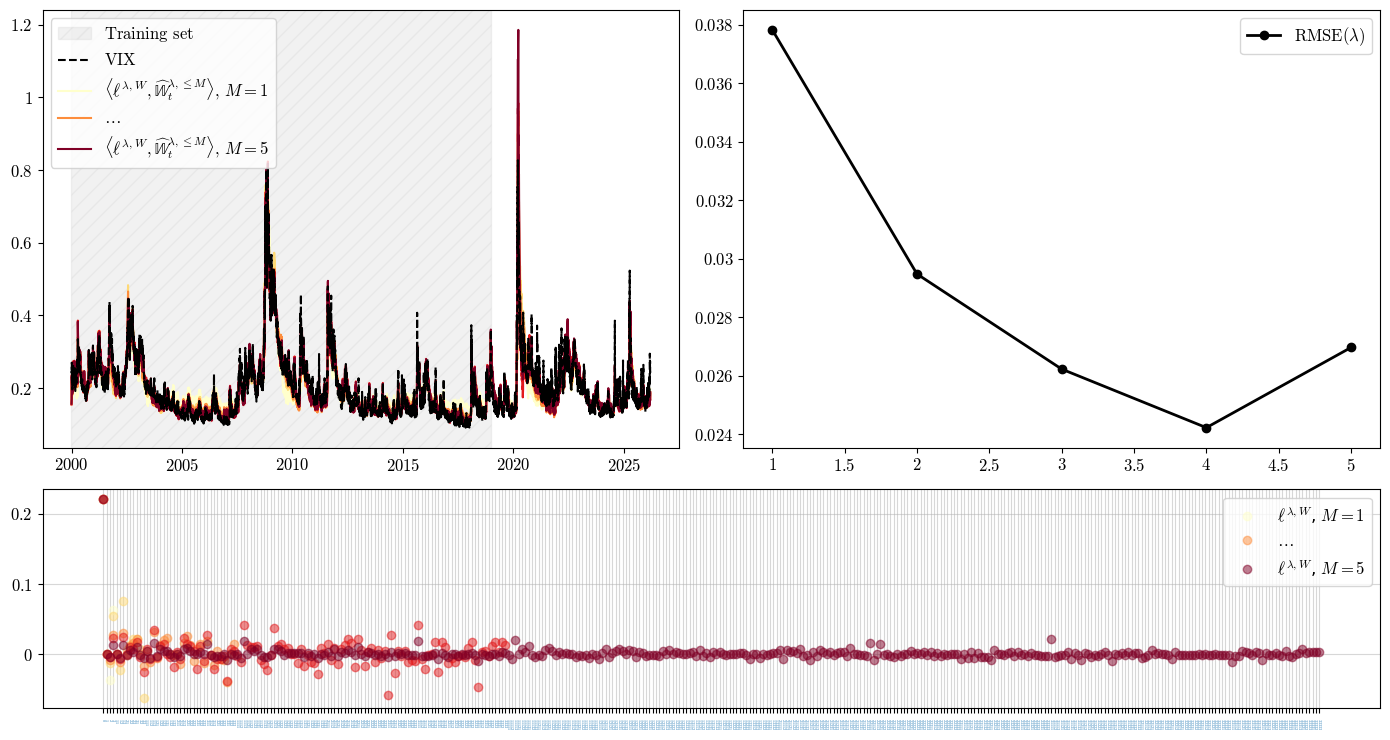

In [307]:
cmap = plt.get_cmap("YlOrRd", len(M_values))
norm = mcolors.Normalize(vmin=M_values.min(), vmax=M_values.max())
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig = plt.figure(figsize=(14, 7.5))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

ax = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, :]),
]
ax[0].axvspan(xmin=dates_grid[idx_train-1], xmax=dates_grid[idx_test], color="lightgray", hatch="//", alpha=0.30, label=r"$\text{Training set}$", zorder=0)
ax[0].plot(dates_grid[idx_train-1:], Y, color="black", label=r"$\text{VIX}$", zorder=1, linestyle="--")
for i, M in enumerate(M_values) : 
    color = cmap(norm(M))
    if i == 0 or i == len(M_values)-1 : 
        ax[0].plot(dates_grid[idx_train-1:], Y_EFM_values[i], color=color, zorder=0, label=r"$\left\langle \ell^{\lambda, W}, \widehat{\mathbb{W}}_t^{\lambda, \leq M}\right\rangle,\,$" + fr"$M={M}$")  
        l_values[i].plot(ax=ax[2], size_x=3, alpha=0.5, color=color, label=r"$\ell^{\lambda, W}$, " + fr"$M={M}$")  
    elif i == len(M_values)//2 :
        ax[0].plot(dates_grid[idx_train-1:], Y_EFM_values[i], color=color, zorder=0, label=r"$\ldots$")
        l_values[i].plot(ax=ax[2], size_x=3, alpha=0.5, color=color, label=r"$\ldots$")
    else : 
        ax[0].plot(dates_grid[idx_train-1:], Y_EFM_values[i], color=color, zorder=0)
        l_values[i].plot(ax=ax[2], size_x=3, alpha=0.5, color=color)
ax[1].plot(M_values, RMSE_values, "o-", lw=2, color="black", label=r"$\text{RMSE}(\lambda)$")

for i in [0,1] : 
    ax[i].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
    ax[i].tick_params(labelsize=12, axis="both")
    ax[i].legend(fontsize=12)

ax[0].xaxis.set_major_locator(mdates.YearLocator(5))        
ax[0].xaxis.set_major_formatter(mdates.DateFormatter(r"$%Y$"))
ax[1].xaxis.set_major_formatter(lambda x, _: f"${x:g}$")
plt.tight_layout()
plt.savefig("tt.pdf")
plt.show()

### I.3. Cross validation for $\boldsymbol{\lambda}$

In [145]:
t_grid_ = t_grid - t_grid[idx_train-1]
path = np.vstack([t_grid_, np.log(SPX) / 10,
    np.concatenate([[0], np.cumsum(np.diff(np.log(SPX))**2)]) * 2,
]).T
lambd = [10, 10, 10]
M = 2
Y = np.array(VIX[idx_train-1:])
sig_EFM = compute_EFM_signature_one_path(path, M, t_grid_, lambd)

bounds = [(5, 20), (5, 20), (1, 20)]
init_guess = [10] * len(lambd)
lambd_opt = minimize_lambda_cv_ridge(path, Y, M, idx_train-1, bounds, n_splits=5, init_guess=init_guess)

lambda=[10. 10. 10.] | CV MSE=0.026101
lambda=[10.72949017 10.         10.        ] | CV MSE=0.026176
lambda=[14.27050983 10.         10.        ] | CV MSE=0.026385
lambda=[ 8.54101966 10.         10.        ] | CV MSE=0.025905
lambda=[ 7.18847051 10.         10.        ] | CV MSE=0.025653
lambda=[ 6.35254916 10.         10.        ] | CV MSE=0.025455
lambda=[ 5.83592135 10.         10.        ] | CV MSE=0.025312
lambda=[ 5.51662781 10.         10.        ] | CV MSE=0.025216
lambda=[ 5.31929354 10.         10.        ] | CV MSE=0.025153
lambda=[ 5.19733426 10.         10.        ] | CV MSE=0.025113
lambda=[ 5.12195928 10.         10.        ] | CV MSE=0.025087
lambda=[ 5.07537498 10.         10.        ] | CV MSE=0.025071
lambda=[ 5.0465843 10.        10.       ] | CV MSE=0.025061
lambda=[ 5.02879068 10.         10.        ] | CV MSE=0.025055
lambda=[ 5.01779362 10.         10.        ] | CV MSE=0.025051
lambda=[ 5.01099706 10.         10.        ] | CV MSE=0.025049
lambda=[ 5.00679656

array([16.19140799, 19.12016074,  1.83910082])

In [312]:
lambd_opt

array([16.19140799, 19.12016074,  1.83910082])

In [315]:
sig_EFM = compute_EFM_signature_one_path(path, M, t_grid_, lambd_opt)

In [316]:
start = time.time() 
model_EFM_Ridge, Y_EFM_Ridge, rmse_EFM_Ridge, _ = regression_Ridge(Y, sig_EFM, M, idx_train-1, idx_train-1, verbose=False)  
print("Ridge: ", time.time()-start, " seconds, RMSE:", rmse_EFM_Ridge) 
coef_Ridge = get_full_coef(model_EFM_Ridge)
l_Ridge = Tensor(array=jnp.asarray(coef_Ridge), M=M, d=3)

Ridge:  0.13599371910095215  seconds, RMSE: 0.02385892443533782


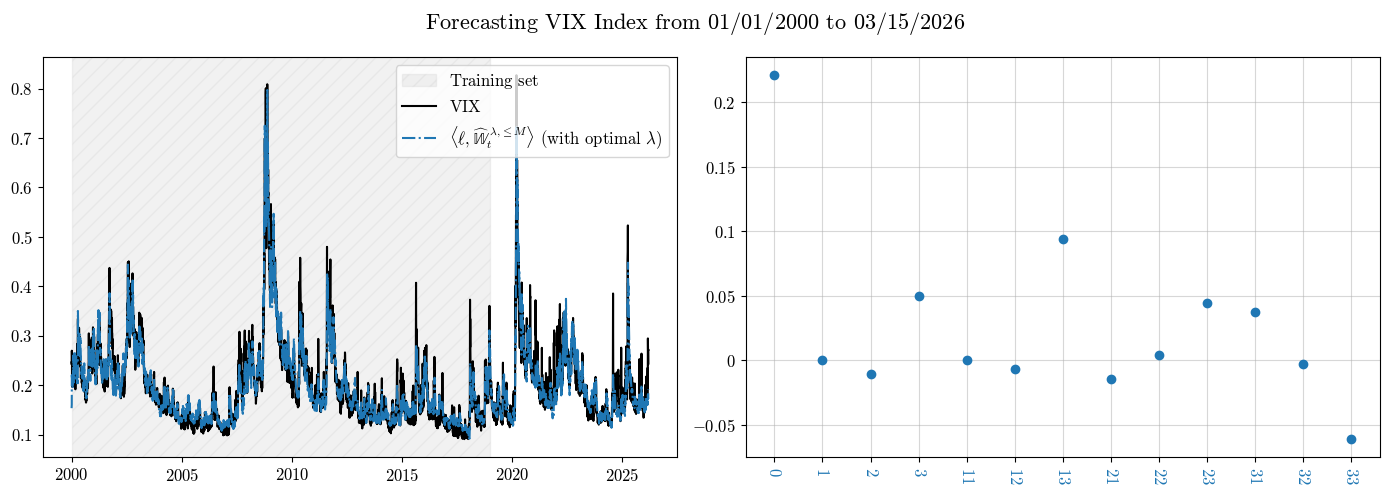

In [317]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))
ax[0].axvspan(xmin=dates_grid[idx_train-1], xmax=dates_grid[idx_test], color="lightgray", hatch="//", alpha=0.30, label=r"$\text{Training set}$")
ax[0].plot(dates_grid[idx_train-1:], Y, color="black", label=r"$\text{VIX}$")
ax[0].plot(dates_grid[idx_train-1:], Y_EFM_Ridge, linestyle="-.", color="tab:blue", label=r"$\left\langle \ell, \widehat{\mathbb{W}}_t^{\,\,\lambda, \!\leq M}\right\rangle \text{ (with optimal }\lambda\text{)}$")
ax[0].legend(fontsize=12)

l_Ridge.plot(ax=ax[1])

ax[0].xaxis.set_major_locator(mdates.YearLocator(5))        
ax[0].xaxis.set_major_formatter(mdates.DateFormatter(r"$%Y$"))
ax[0].yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax[0].tick_params(labelsize=12, axis="both")
fig.suptitle(r"$\text{Forecasting VIX Index from 01/01/2000 to 03/15/2026}$", fontsize=16)

plt.tight_layout()
plt.show()

## II. Forecasting the realized volatility of the SPX 

In [2]:
df = pd.read_csv("spx.csv", index_col=0, parse_dates=True)
spx = df[df['Symbol'] == '.SPX'].copy()
spx = spx.sort_index()
spx.index = pd.to_datetime(spx.index, utc=True).tz_convert(None) 
index = spx.index

log_prices = np.log(spx['close_price'].values)  
realized_vol = np.sqrt(spx['medrv'].values)
log_returns = np.diff(log_prices)
rv_daily = np.abs(log_returns)
rv_5 = pd.Series(log_returns**2).rolling(5).sum().values
rv_5 = np.sqrt(rv_5 / 5)
rv_22 = pd.Series(log_returns**2).rolling(22).sum().values
rv_22 = np.sqrt(rv_22 / 22)

dates_grid = pd.to_datetime(pd.Series(index))

train_start_date = pd.Timestamp('2005-01-03')
test_start_date = pd.Timestamp('2014-01-03')
test_end_date = pd.Timestamp('2018-06-27')

idx_train = np.where(index >= train_start_date)[0][0]
idx_test = np.where(index >= test_start_date)[0][0]

print(f"Train start: {index[idx_train]}, idx={idx_train}")
print(f"Test start: {index[idx_test]}, idx={idx_test}")

t_grid = np.array((index - index[0]).days / 252)
t_grid_ = t_grid - t_grid[idx_train - 1]

Train start: 2005-01-03 00:00:00, idx=1246
Test start: 2014-01-03 00:00:00, idx=3512


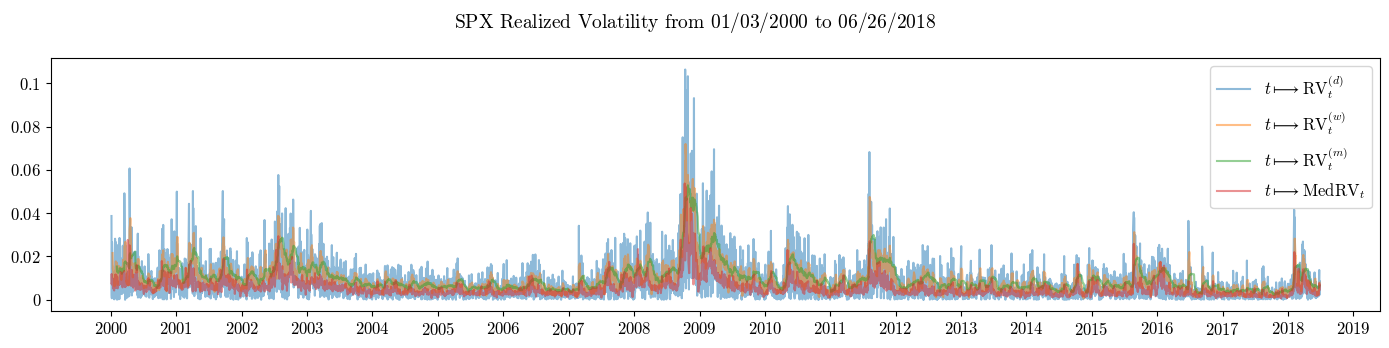

In [3]:
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.plot(index[1:], rv_daily, color="tab:blue", alpha=0.5, label=r"$t\longmapsto \text{RV}_t^{(d)}$") 
ax.plot(index[5:], rv_5[4:], color="tab:orange", alpha=0.5, label=r"$t\longmapsto \text{RV}_t^{(w)}$") 
ax.plot(index[22:], rv_22[21:], color="tab:green", alpha=0.5, label=r"$t\longmapsto \text{RV}_t^{(m)}$") 
ax.plot(index, realized_vol, color="tab:red", alpha=0.5, label=r"$t\longmapsto \text{MedRV}_t$") 

ax.xaxis.set_major_locator(mdates.YearLocator(1))        
ax.xaxis.set_major_formatter(mdates.DateFormatter(r"$%Y$"))
ax.yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax.tick_params(labelsize=12, axis="both")
ax.legend(fontsize=12)
fig.suptitle(r"$\text{SPX Realized Volatility from }01/03/2000 \text{ to }06/26/2018$", fontsize=14)

plt.tight_layout()
plt.show()

In [4]:
q = 1 
Y_pred_HAR, Y_test_HAR, model_HAR, R2_HAR, RMSE_HAR = fit_HAR(realized_vol, idx_train, idx_test, q)
print(fr"HAR: RMSE = {RMSE_HAR} | R2 = {R2_HAR}")

HAR: RMSE = 0.001677516971345371 | R2 = 0.5630581170160464


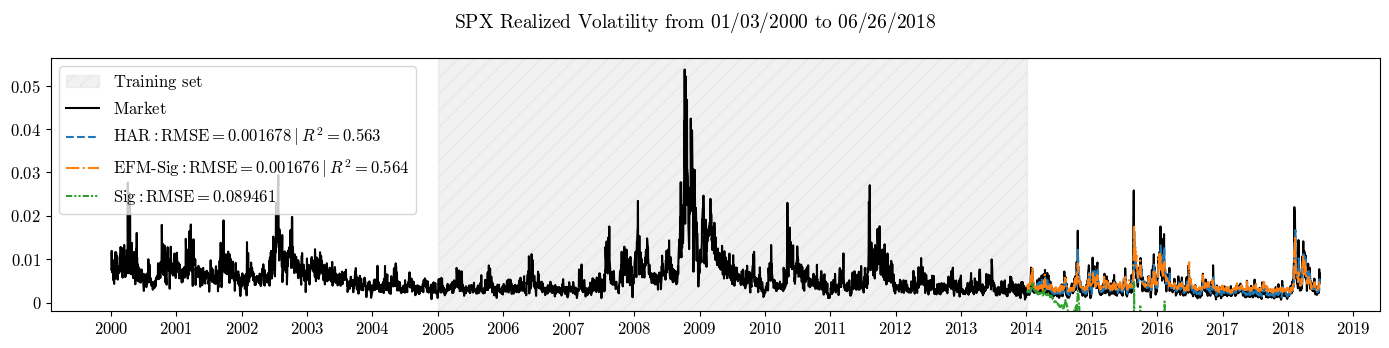

In [20]:
fig, ax = plt.subplots(figsize=(14, 3.5))
ax.axvspan(xmin=dates_grid[idx_train], xmax=dates_grid[idx_test], color="lightgray", hatch="//", alpha=0.30, label=r"$\text{Training set}$")
ax.plot(index, realized_vol, color="black", label=r"$\text{Market}$") 
ax.plot(index[idx_test+1:], Y_pred_HAR, color="tab:blue", linestyle="--", label=r"$\text{HAR}: \text{RMSE}$" + fr"$= {np.round(RMSE_HAR,6)}\:|\: R^2 = {np.round(R2_HAR, 3)}$")
ax.plot(index[idx_test+1:], best_Y_EFM[idx_test-idx_train+1:], color="tab:orange", linestyle="-.", label=r"$\text{EFM-Sig}: \text{RMSE}$" + fr"$= {np.round(RMSE_EFM,6)}\:|\: R^2 = {np.round(R2_EFM, 3)}$")
lims = ax.get_ylim()
ax.plot(index[idx_test+1:], Y_SIG_Ridge[idx_test-idx_train+1:], color="tab:green", linestyle=(0, (3, 1, 1, 1, 1, 1)), label=r"$\text{Sig}: \text{RMSE}$" + fr"$= {np.round(RMSE_SIG,6)}$")
ax.set_ylim(lims)
ax.xaxis.set_major_locator(mdates.YearLocator(1))        
ax.xaxis.set_major_formatter(mdates.DateFormatter(r"$%Y$"))
ax.yaxis.set_major_formatter(lambda y, _: f"${y:g}$")
ax.tick_params(labelsize=12, axis="both")
ax.legend(loc="upper left", fontsize=12)
fig.suptitle(r"$\text{SPX Realized Volatility from }01/03/2000 \text{ to }06/26/2018$", fontsize=14)

plt.tight_layout()
plt.show()

In [7]:
path = np.vstack([
    t_grid_, 
    log_prices / 10, 
    np.concatenate([[0], np.cumsum(np.diff(log_prices)**2)]) * 2
]).T

d = path.shape[1]
lambda_values = np.linspace(1, 20, 20)
M = 6
q = 1

Y_full = np.array(realized_vol)
n_train = idx_test - (idx_train - 1)
n_val   = n_train

Y_EFM_values, RMSE_values, l_values = [], [], []

for lambd in tqdm(lambda_values):
    sig_EFM = compute_EFM_signature_one_path(path, M, t_grid_, lambd)
    
    sig_EFM_shifted = sig_EFM[:, :-q]       
    Y_shifted = Y_full[idx_train - 1 + q:]  
    
    model_EFM_Ridge, Y_EFM_Ridge, rmse_EFM_Ridge, _ = regression_Ridge(
        Y_shifted,
        sig_EFM_shifted,
        M,
        n_train,
        n_train,
        verbose=False
    )
    
    coef_Ridge = get_full_coef(model_EFM_Ridge)
    l_Ridge = Tensor(array=jnp.asarray(coef_Ridge), M=M, d=d)
    Y_EFM_values.append(Y_EFM_Ridge)
    l_values.append(l_Ridge)
    RMSE_values.append(rmse_EFM_Ridge)

100%|███████████████████████████████████████████| 20/20 [06:04<00:00, 18.21s/it]


In [9]:
best_idx = np.argmin(RMSE_values)
best_lambda = lambda_values[best_idx]
best_rmse = RMSE_values[best_idx]
best_l = l_values[best_idx]
best_Y_EFM = Y_EFM_values[best_idx]

Y_test = Y_shifted[n_train:]
Y_pred_EFM = best_Y_EFM[n_train:]
RMSE_EFM = np.sqrt(np.mean((Y_pred_EFM - Y_test)**2))
R2_EFM = 1 - np.mean((Y_pred_EFM - Y_test)**2) / np.var(Y_test)

print(fr"EFM: RMSE = {RMSE_EFM} | R2 = {R2_EFM} | lambda = {best_lambda}")

EFM: RMSE = 0.001675700365874032 | R2 = 0.5640039449832905 | lambda = 13.0


In [11]:
path = np.vstack([
    t_grid_, 
    log_prices / 10, 
    np.concatenate([[0], np.cumsum(np.diff(log_prices)**2)]) * 2
]).T

d = path.shape[1]
lambda_values = np.linspace(1, 20, 20)
M = 6
q = 1

Y_full = np.array(realized_vol)
n_train = idx_test - (idx_train - 1)
n_val   = n_train

Y_SIG_values, RMSE_values, l_values = [], [], []

sig = compute_signature(path[None, idx_train-1:, :], M)[:, :, 0]
    
sig_shifted = sig[:, :-q]       
Y_shifted = Y_full[idx_train - 1 + q:]  
    
model_SIG_Ridge, Y_SIG_Ridge, rmse_SIG_Ridge, _ = regression_Ridge(
    Y_shifted,
    sig_shifted,
    M,
    n_train,
    n_train,
    verbose=False)

Y_test = Y_shifted[n_train:]
Y_pred_SIG = Y_SIG_Ridge[n_train:]
RMSE_SIG = np.sqrt(np.mean((Y_pred_SIG - Y_test)**2)) 
R2_SIG = 1 - np.mean((Y_pred_SIG - Y_test)**2) / np.var(Y_test)
print(fr"SIG: RMSE = {RMSE_SIG} | R2 = {R2_SIG}")

SIG: RMSE = 0.08946098127631513 | R2 = -1241.6738110099345
